Setup untuk Google Colab(T4 GPU)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import sys
import os
import json
import pickle
import pathlib
import pandas as pd
import numpy as np

PROJECT = "/content/ml_pipeline"
if not os.path.exists(PROJECT):
    import subprocess
    subprocess.run(["git", "clone",
                    "https://github.com/Fawwzrf/PhishingDetector.git",
                    PROJECT])

sys.path.insert(0, f"{PROJECT}/src")

import shutil
DRIVE_PROJECT = "/content/drive/MyDrive/PhishingDetector"

for folder in ["data", "models", "logs", "reports"]:
    local_path = f"{PROJECT}/{folder}"
    drive_path = f"{DRIVE_PROJECT}/{folder}"
    if os.path.isdir(local_path) and not os.path.islink(local_path):
        shutil.rmtree(local_path)
    if not os.path.exists(local_path):
        os.symlink(drive_path, local_path)

os.chdir(PROJECT)
!pip install -e . -q
!pip install -r requirements.txt -q

from mltools          import MLConfig
from mltools.shared.logging import setup_logging

config = MLConfig.from_yaml("configs/ml_config.yaml")
setup_logging(log_level="INFO", experiment=config.project.name)

print("Setup selesai!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import joblib
import pickle
import json
import pandas as pd
from loguru import logger

with open("models/modeling_meta.json") as f:
    meta = json.load(f)

champion_name   = meta["champion_name"]
optimal_thr     = meta["optimal_threshold"]
feature_names   = meta["feature_names"]
all_scores      = meta["all_scores"]
test_metrics    = meta["test_metrics"]

logger.info(f"Champion model : {champion_name}")
logger.info(f"Test ROC-AUC   : {test_metrics['roc_auc']:.4f}")
logger.info(f"Test F1        : {test_metrics['f1_optimal']:.4f}")
logger.info(f"Threshold opt. : {optimal_thr:.4f}")
logger.info(f"N features     : {len(feature_names)}")

final_model = joblib.load(meta["champion_model_path"])
logger.success(f"Model loaded: {type(final_model).__name__}")

X_train = pd.read_parquet(meta["data_paths"]["X_train"])
X_test  = pd.read_parquet(meta["data_paths"]["X_test"])
y_test  = pd.read_parquet(meta["data_paths"]["y_test"]).squeeze()

assert list(X_train.columns) == feature_names, \
    "Feature names tidak cocok! Ada perubahan preprocessing?"
logger.success(f"Data loaded dan verified: X_test={X_test.shape}")

print("\n" + "="*50)
print("  SUMMARY DARI MODELING.IPYNB")
print("="*50)
print("  All model scores (val):")
for name, score in sorted(all_scores.items(),
                           key=lambda x: x[1], reverse=True):
    flag = " ← champion" if name == champion_name else ""
    print(f"    {name:<20}: {score:.4f}{flag}")
print(f"\n  Test metrics:")
for k, v in test_metrics.items():
    print(f"    {k:<20}: {v:.4f}")
print("="*50)

20:17:00 | INFO     | __main__:18 | Champion model : lightgbm
20:17:00 | INFO     | __main__:19 | Test ROC-AUC   : 0.9915
20:17:00 | INFO     | __main__:20 | Test F1        : 0.9397
20:17:00 | INFO     | __main__:21 | Threshold opt. : 0.5222
20:17:00 | INFO     | __main__:22 | N features     : 24
20:17:05 | SUCCESS  | __main__:26 | Model loaded: LGBMClassifier
20:17:08 | SUCCESS  | __main__:37 | Data loaded dan verified: X_test=(13082, 24)

  SUMMARY DARI MODELING.IPYNB
  All model scores (val):
    lightgbm            : 0.9909 ← champion
    xgboost             : 0.9900
    random_forest       : 0.9898

  Test metrics:
    roc_auc             : 0.9915
    f1_default          : 0.9407
    f1_optimal          : 0.9397
    accuracy            : 0.9578


SHAP Analysis

20:19:18 | INFO     | mltools.interpretation.shap_analysis:64 | SHAP Explainer: tree
20:19:22 | WARNING  | mltools.interpretation.shap_analysis:130 | Subsampling dari 13,082 ke 2,000 untuk efisiensi SHAP
20:19:22 | INFO     | mltools.interpretation.shap_analysis:136 | Computing SHAP values untuk 2,000 samples...


100%|===================| 1994/2000 [03:48<00:00]       

20:23:11 | SUCCESS  | mltools.interpretation.shap_analysis:158 | SHAP values computed: (2000, 24)
20:23:11 | INFO     | mltools.interpretation.shap_analysis:352 | Running full SHAP analysis...


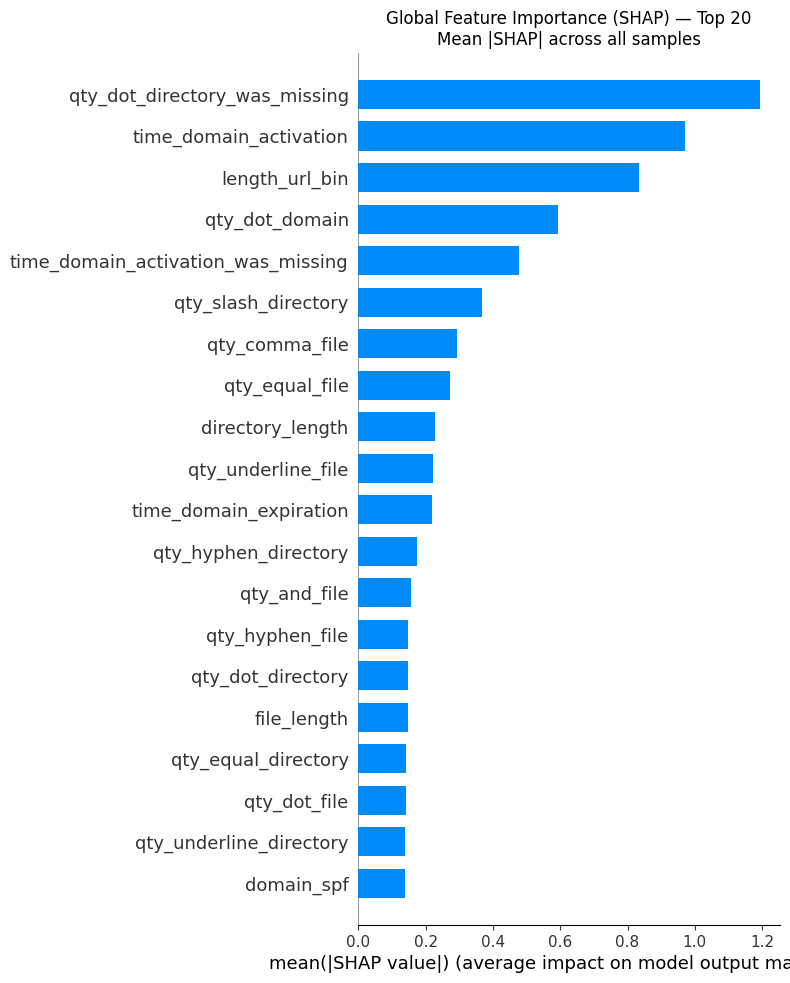

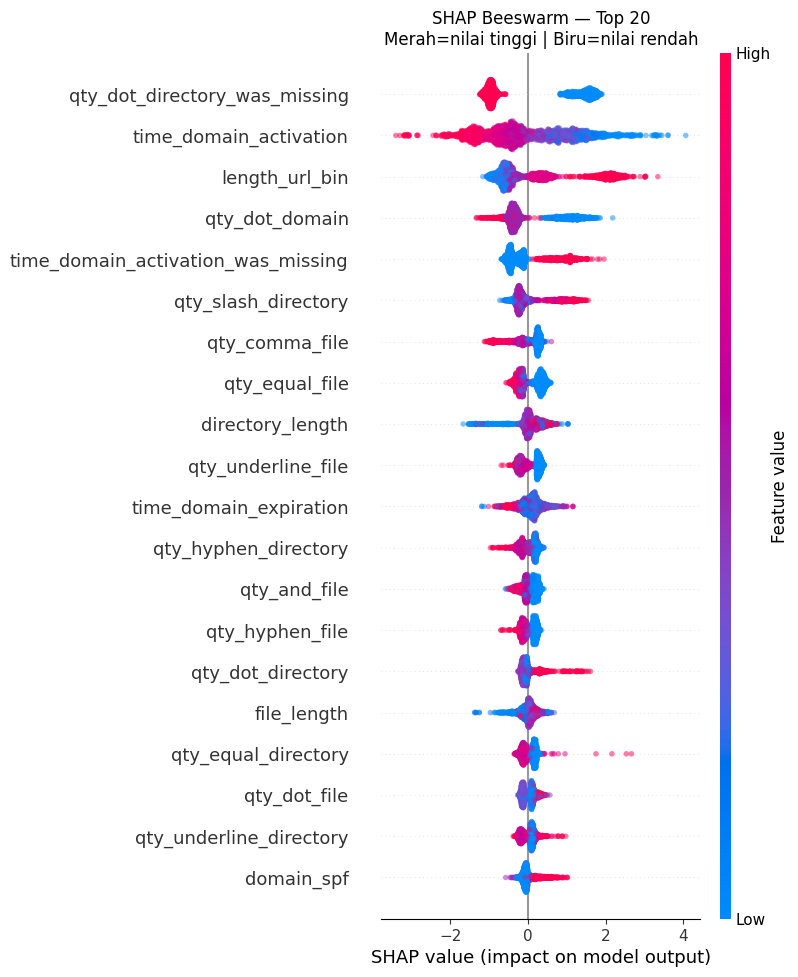

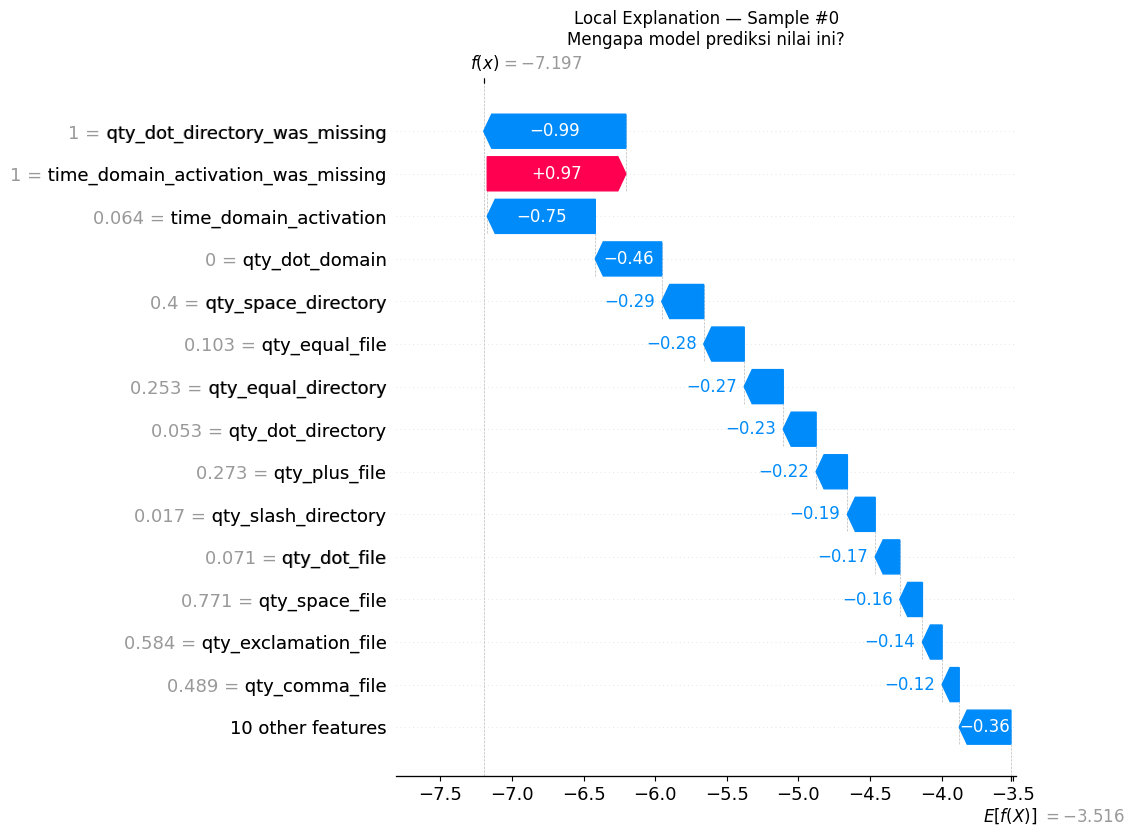

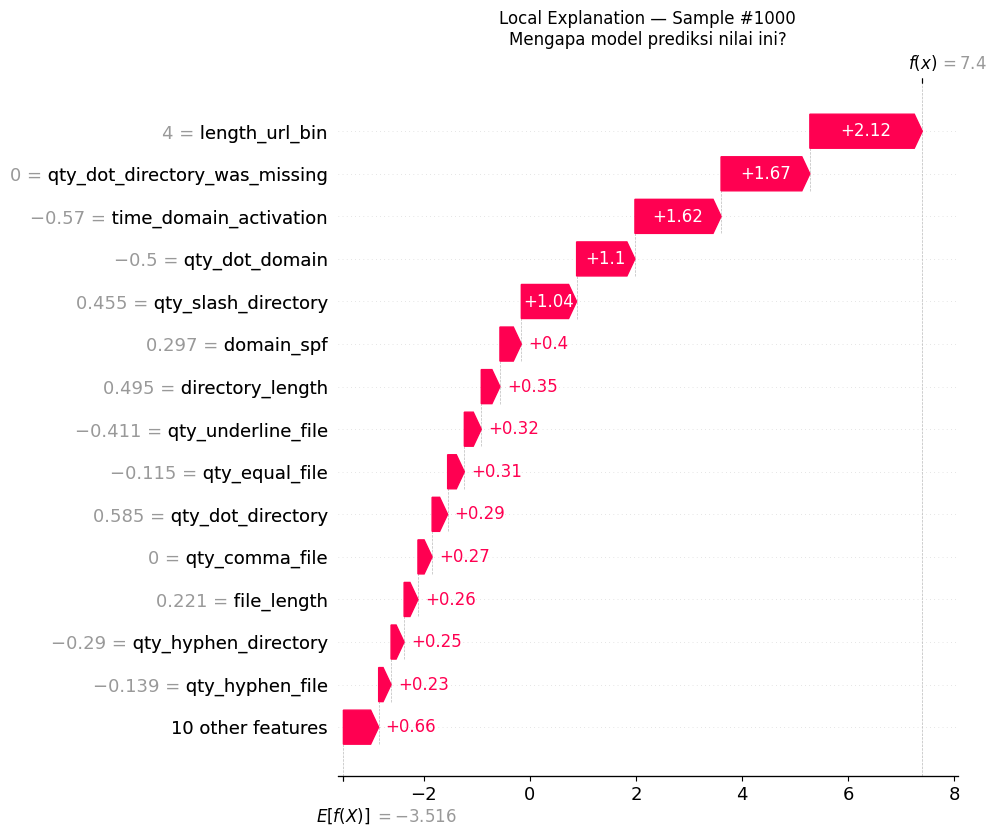

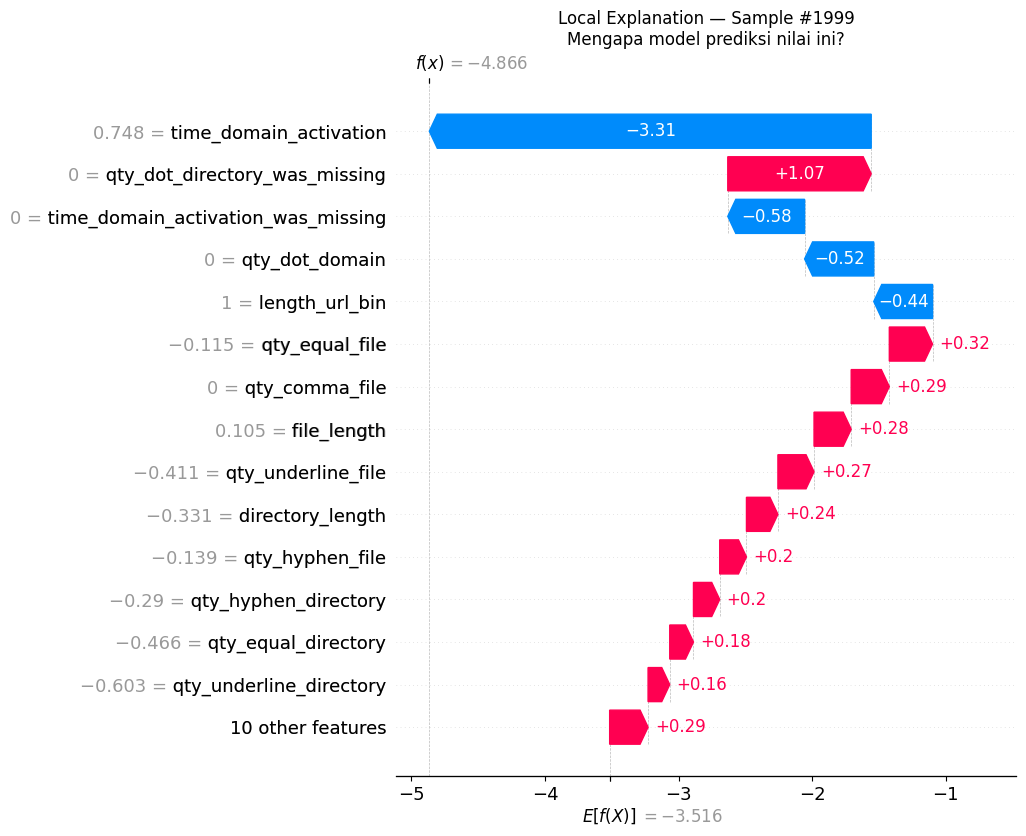

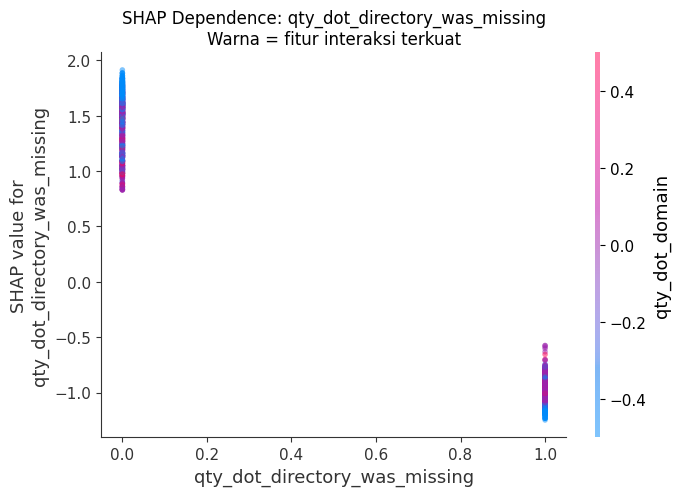

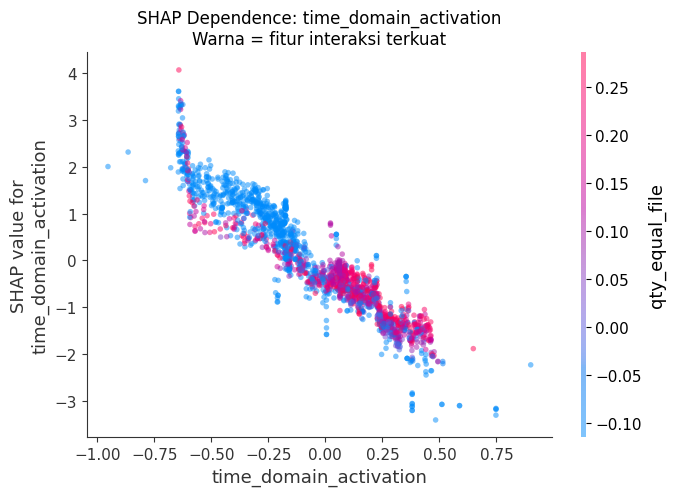

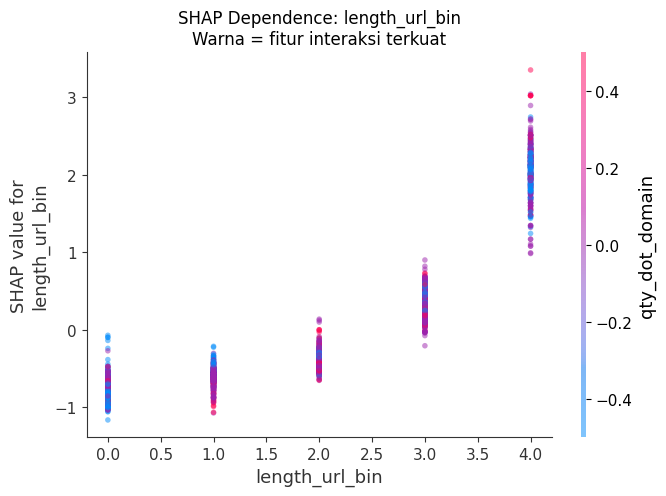

20:23:20 | SUCCESS  | mltools.interpretation.shap_analysis:374 | SHAP importance saved: reports/shap_importance.csv
20:23:20 | SUCCESS  | mltools.interpretation.shap_analysis:375 | Full SHAP analysis selesai! Check reports/

Top 10 fitur terpenting:
 rank                            feature  mean_abs_shap
    1      qty_dot_directory_was_missing       1.193575
    2             time_domain_activation       0.970765
    3                     length_url_bin       0.832839
    4                     qty_dot_domain       0.592943
    5 time_domain_activation_was_missing       0.478611
    6                qty_slash_directory       0.366323
    7                     qty_comma_file       0.294061
    8                     qty_equal_file       0.272512
    9                   directory_length       0.227532
   10                 qty_underline_file       0.222404


In [4]:
from mltools.interpretation import SHAPAnalyzer

analyzer = SHAPAnalyzer(
    model         = final_model,
    X_background  = X_train,
    feature_names = X_train.columns.tolist(),
    task          = config.modeling.task,
    n_background  = 500,
)

analyzer.full_analysis(X_test, top_n=20)

importance_df = analyzer.get_importance_df()
importance_df.to_csv("reports/shap_importance.csv", index=False)

print("\nTop 10 fitur terpenting:")
print(importance_df.head(10)[["rank", "feature", "mean_abs_shap"]].to_string(index=False))